<a href="https://colab.research.google.com/github/baldiea75-tech/carisurg-portfolio/blob/feat%2FWeek-5-refactor/Week5_Interim_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border-radius:10px;overflow:hidden;font-family:'Times New Roman',Times,serif;border:1px solid #e0e0e0;">
<div style="background:linear-gradient(135deg,#6A2D8A,#E05FA0);padding:22px 28px;color:white;">
<h1 style="margin:0;font-size:26px;">Week 5 Interim Deliverable</h1>
<p style="margin:6px 0 0 0;font-size:15px;opacity:0.95;">Data Exploration, Profiling and Quality Assessment</p>
</div>
<div style="padding:14px 28px;background:#f7f9fb;">
<b>Dataset:</b> Yale EMMLC Admission Prediction Triage (<code>yaleemmlc_admissionprediction_triage.csv</code>) &nbsp;&#8226;&nbsp;
<b>Author:</b> Ashi Baldie &nbsp;&#8226;&nbsp; <b>Programme:</b> CariSurg MedTech Pathways 2026
</div>
</div>


## Goal

Dr. De Fretias and the ED Board need to know one thing before Week 6 modelling starts. Is this dataset good enough to build a triage model from?

This notebook profiles the raw data from start to finish: structure, types, missingness, outliers and the relationships that matter clinically, so the feasibility memo (`docs/week5_feasibility_memo.md`) rests on evidence rather than intuition. It follows directly from Tutorials 1 to 3 (Literacy, then Profiling, then Visualisation).

## 1. Setup

In [ ]:
print("Environment ready.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

Environment ready.
pandas 3.0.2 | numpy 2.4.4


## 2. Load the Data

With 225 columns, the first question is always the simplest one. Did it load, and is it the shape we expect?

In [ ]:
DATA_PATH = "/mnt/user-data/uploads/yaleemmlc_admissionprediction_triage.csv"
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")
print(f"Shape: {df.shape}")

Loaded 55,121 encounters x 225 columns
Shape: (55121, 225)


## 3. Column Families (Schema Map)

225 columns is too many to reason about individually, so, as in Tutorial 2, we sort them into families once and refer to the families for the rest of the notebook. `disposition` and `previousdispo` are flagged as **leakage**. Both are only known after the ED visit concludes, so neither can ever be a model input.

In [ ]:
TARGET = "esi"
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]
CC_COLS = [c for c in df.columns if c.startswith("cc_")]
STRUCTURED = [c for c in df.columns if not c.startswith("cc_")]

print(f"Target column:            {TARGET}")
print(f"Vital sign columns:       {len(VITALS)}")
print(f"Demographic columns:      {len(DEMOGRAPHICS)}")
print(f"Admin columns:            {len(ADMIN)}")
print(f"Leakage columns:          {len(LEAKAGE)} -> {LEAKAGE}")
print(f"Chief complaint columns:  {len(CC_COLS)}")
print(f"Structured (non-cc) cols: {len(STRUCTURED)}")
print(f"Total columns:            {df.shape[1]}")

Target column:            esi
Vital sign columns:       7
Demographic columns:      9
Admin columns:            5
Leakage columns:          2 -> ['disposition', 'previousdispo']
Chief complaint columns:  200
Structured (non-cc) cols: 25
Total columns:            225


## 4. Structural Profiling: `.shape` and `.info()`

Before summarising values, we confirm the DataFrame's basic shape and dtype layout. `.info()` on the full 225 column frame is unwieldy, so we also run it on just the 25 structured (non chief complaint) columns, where the dtype detail is actually readable.

In [ ]:
print("df.shape ->", df.shape)
print()
df.info(verbose=False)
print()
print("Structured-column dtypes (df[STRUCTURED].info):")
df[STRUCTURED].info(max_cols=30, verbose=True, show_counts=True)

df.shape -> (55121, 225)

<class 'pandas.DataFrame'>
Index: 55121 entries, 7 to 433332
Columns: 225 entries, dep_name to cc_wristpain
dtypes: float64(210), str(15)
memory usage: 95.0 MB

Structured-column dtypes (df[STRUCTURED].info):
<class 'pandas.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  str    
 1   esi                     55121 non-null  float64
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  str    
 4   ethnicity               55121 non-null  str    
 5   race                    55121 non-null  str    
 6   lang                    55121 non-null  str    
 7   religion                55121 non-null  str    
 8   maritalstatus           55121 non-null  str    
 9   employstatus            55121 non-null  str    
 10  insurance_status        55121 

## 5. `.describe()`: Numeric and Categorical

`.describe()` on the numeric structured columns gives us count, mean, standard deviation and quartiles for age, vitals and the target. `.describe(include='object')` does the same for the categorical columns, including count, number of unique values and the most frequent category.

In [ ]:
print("=== df.describe(). numeric structured columns ===")
numeric_structured = df[STRUCTURED].select_dtypes(include="number")
print(numeric_structured.describe().T.round(2))

print()
print("=== df.describe(include='object'). categorical structured columns ===")
cat_structured = df[STRUCTURED].select_dtypes(exclude="number")
print(cat_structured.describe().T)

=== df.describe(). numeric structured columns ===
                          count    mean    std   min    25%    50%    75%     max
esi                     55121.0    2.88   0.75   1.0    2.0    3.0    3.0     5.0
age                     55121.0   55.32  19.54  18.0   40.0   55.0   70.0   107.0
triage_vital_hr         55121.0   86.45  16.96  32.0   74.0   85.0   97.0   221.0
triage_vital_sbp        55121.0  133.68  22.65  53.0  118.0  132.0  147.0   266.0
triage_vital_dbp        55121.0   79.53  14.59  27.0   70.0   79.0   89.0   189.0
triage_vital_rr         55121.0   17.84   2.07   8.0   16.0   18.0   18.0    66.0
triage_vital_o2         55121.0   97.02   2.08  62.0   96.0   98.0   98.0    99.0
triage_vital_o2_device  55121.0    0.07   0.25   0.0    0.0    0.0    0.0     1.0
triage_vital_temp       55121.0   98.09   0.81  91.5   97.7   98.0   98.4   106.0
triage_glucose          55121.0  130.09  73.66  16.0   93.0  107.0  134.0  1066.0

=== df.describe(include='object'). categorical 

## 6. Dtype Audit

A dtype audit checks for two kinds of mismatch.

1. **String columns that are secretly numbers** (mis-typed as text). None found here. All 15 string columns are genuine categories such as gender, race and arrival day.
2. **Float columns that are secretly something else**, specifically whole-number-only floats that are really binary flags or ordinal categories rather than continuous measurements.

This matters because it changes how a column should be treated in Week 6 modelling, even though it causes no problems for the profiling done here.

In [ ]:
print("=== Dtype Audit ===")
print()
dtype_counts = df.dtypes.value_counts()
print("Column counts by dtype:")
print(dtype_counts)
print()

# 1. Are any "numeric-looking" string columns actually mis-typed as text?
obj_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype) == "str"]
mistyped_as_text = []
for c in obj_cols:
    sample = df[c].dropna().astype(str)
    if len(sample) == 0:
        continue
    numeric_like = pd.to_numeric(sample, errors="coerce").notna().mean()
    if numeric_like > 0.95:
        mistyped_as_text.append(c)
print(f"String-typed columns: {len(obj_cols)}")
print(f"  -> of these, columns that are actually numeric text (mis-typed): {len(mistyped_as_text)}")
label = mistyped_as_text if mistyped_as_text else "None found. All string columns are genuine categories."
print(f"     {label}")
print()

# 2. Are any float64 columns actually whole-number / binary flags that should be a smaller dtype?
float_cols = df.select_dtypes(include="float64").columns.tolist()
whole_number_cols = [c for c in float_cols if np.all(df[c].dropna() == df[c].dropna().round())]
binary_cols = [c for c in whole_number_cols if set(df[c].dropna().unique()) <= {0.0, 1.0}]
ordinal_not_binary = [c for c in whole_number_cols if c not in binary_cols]

print(f"Float64 columns:                         {len(float_cols)}")
print(f"  -> whole-number-only (no decimals):    {len(whole_number_cols)}")
print(f"      -> binary 0/1 flags stored as float64: {len(binary_cols)}")
cc_in_binary = [c for c in binary_cols if c.startswith("cc_")]
non_cc_binary = [c for c in binary_cols if not c.startswith("cc_")]
print(f"          ({len(cc_in_binary)} of these are cc_* chief-complaint flags,")
print(f"           {len(non_cc_binary)} are other binary flags: {non_cc_binary})")
print(f"      -> whole-number but not binary (ordinal/count): {ordinal_not_binary}")
print()
print("Key finding: 'esi' (our target) is stored as float64 but is really a 5-level")
print("ordinal category (1-5). 'age' is float64 but always a whole number of years.")
print("All 200 cc_* flags and 'triage_vital_o2_device' are binary but stored as float64 --")
print("harmless for analysis, but should be cast to int8/category before modelling in Week 6")
print("to save memory and make the intent of each column explicit.")

=== Dtype Audit ===

Column counts by dtype:
float64    210
str         15
Name: count, dtype: int64

String-typed columns: 15
  -> of these, columns that are actually numeric text (mis-typed): 0
     None found. All string columns are genuine categories.

Float64 columns:                         210
  -> whole-number-only (no decimals):    204
      -> binary 0/1 flags stored as float64: 192
          (191 of these are cc_* chief-complaint flags,
           1 are other binary flags: ['triage_vital_o2_device'])
      -> whole-number but not binary (ordinal/count): ['esi', 'age', 'triage_glucose', 'cc_abdominalpain', 'cc_abnormallab', 'cc_chestpain', 'cc_epistaxis', 'cc_fall', 'cc_medicalscreening', 'cc_other', 'cc_palpitations', 'cc_uri']

Key finding: 'esi' (our target) is stored as float64 but is really a 5-level
ordinal category (1-5). 'age' is float64 but always a whole number of years.
All 200 cc_* flags and 'triage_vital_o2_device' are binary but stored as float64 --
harmless for

## 7. Missingness: Raw Counts and Percentages

Every column is checked for missing values, reported as **both** a raw count and a percentage of the 55,121 encounters. We look at the worst 10 columns dataset wide, then again restricted to the structured (non chief complaint) columns.

In [ ]:
print("=== Missingness Report (raw counts + percentages) ===")
print()
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing_count, "missing_percent": missing_percent})
missing_table = missing_table.sort_values("missing_count", ascending=False)

print("Top 10 columns by missingness (all columns, all families):")
print(missing_table.head(10))
print()
n_with_gaps = (missing_table["missing_count"] > 0).sum()
print(f"Columns with at least one missing value: {n_with_gaps} of {df.shape[1]}")
print(f"Total missing cells across the whole dataset: {int(df.isna().sum().sum())}")
print()
print("Structured-column missingness (excluding cc_* flags):")
print(missing_table.loc[STRUCTURED].sort_values("missing_count", ascending=False).head(15))
print()
print("Note: zero missingness across all 225 columns is unusually clean for a clinical")
print("dataset. Absence of NaN does not mean absence of bias. Single-site data can")
print("still be systematically skewed even when it is perfectly complete.")

=== Missingness Report (raw counts + percentages) ===

Top 10 columns by missingness (all columns, all families):
               missing_count  missing_percent
dep_name                   0              0.0
esi                        0              0.0
age                        0              0.0
gender                     0              0.0
ethnicity                  0              0.0
race                       0              0.0
lang                       0              0.0
religion                   0              0.0
maritalstatus              0              0.0
employstatus               0              0.0

Columns with at least one missing value: 0 of 225
Total missing cells across the whole dataset: 0

Structured-column missingness (excluding cc_* flags):
                  missing_count  missing_percent
dep_name                      0              0.0
esi                           0              0.0
age                           0              0.0
gender                        

## 8. Missingness Visualisation

A missingness heatmap makes gaps visible at a glance. Red bands would mark columns with the most missing data, against a yellow background for present values. Saved to `docs/figures/missingness_heatmap.png` for the feasibility memo.

Saved: missingness_heatmap.png
At a glance: no column shows a red band, which is consistent with the
0% missingness measured programmatically above. If gaps existed, the worst
columns would appear as solid red rows in this chart.


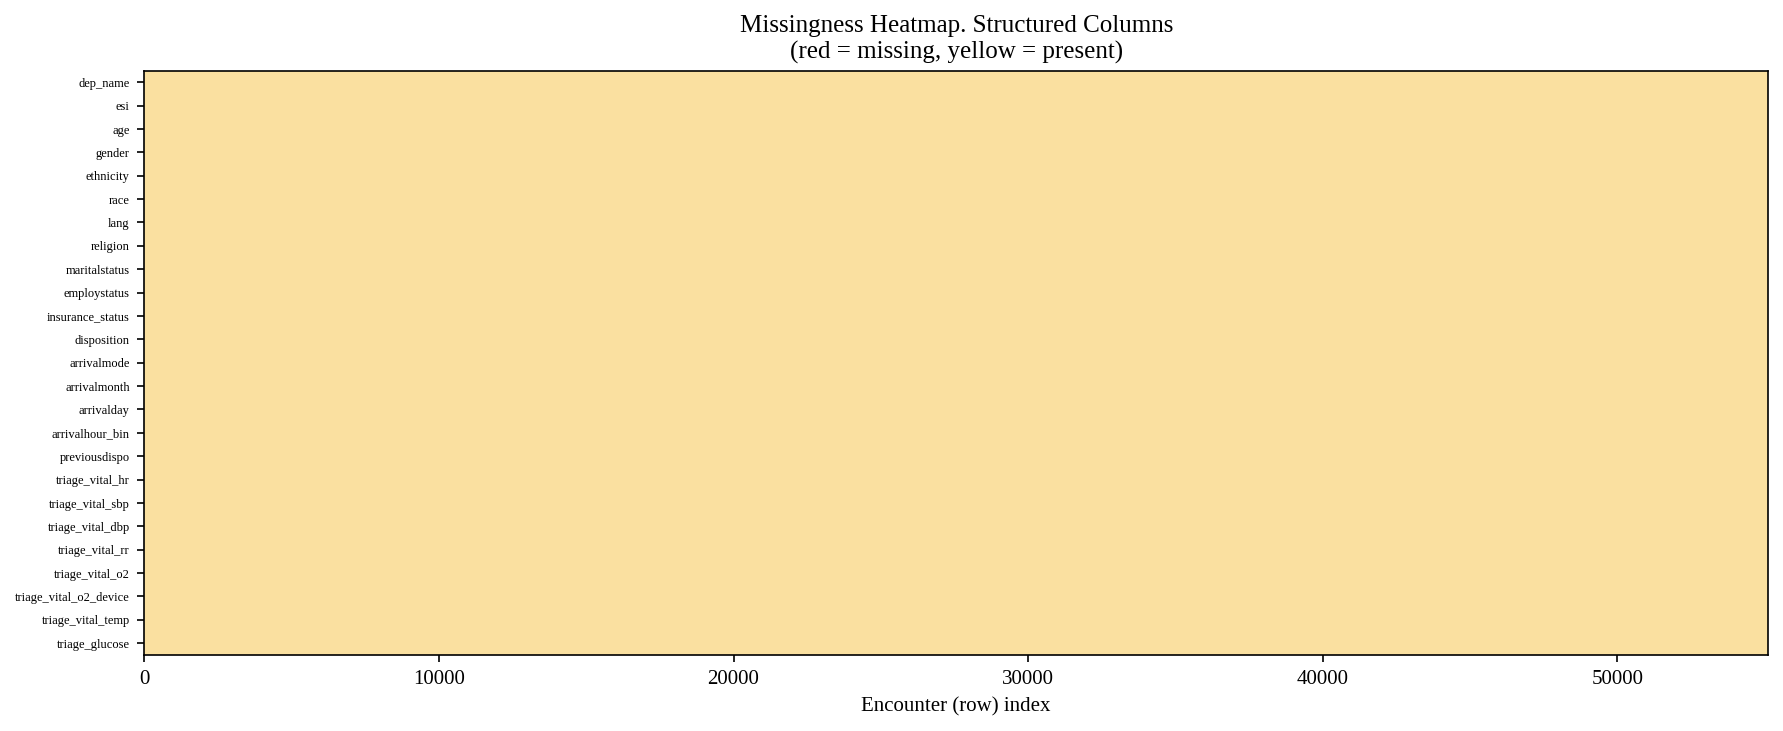

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
missing_matrix = df[STRUCTURED].isna()
ax.imshow(missing_matrix.T.values, aspect="auto", cmap=MISSING_CMAP, vmin=0, vmax=1, interpolation="none")
ax.set_yticks(range(len(STRUCTURED)))
ax.set_yticklabels(STRUCTURED, fontsize=6)
ax.set_xlabel("Encounter (row) index")
ax.set_title("Missingness Heatmap. Structured Columns\n(red = missing, yellow = present)", fontsize=12)
plt.tight_layout()
plt.savefig("/home/claude/build/figs/missingness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: missingness_heatmap.png")
print("At a glance: no column shows a red band, which is consistent with the")
print("0% missingness measured programmatically above. If gaps existed, the worst")
print("columns would appear as solid red rows in this chart.")

## 9. Outlier Report

For each vital sign we count two different kinds of unusual value.
- **Statistical outliers**, meaning values outside the 1.5 times IQR fence. These are expected in any real clinical distribution and not necessarily wrong.
- **Clinically impossible values**, meaning values outside a wide physiologically plausible range. These are almost certainly data errors and need correcting.

In [ ]:
PLAUSIBLE = {"triage_vital_hr": (20,250), "triage_vital_sbp": (50,300), "triage_vital_dbp": (20,200),
             "triage_vital_rr": (4,60), "triage_vital_o2": (50,100), "triage_vital_temp": (86,110),
             "triage_glucose": (20,800)}

def outlier_report(df, col):
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    iqr_outliers = int(((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum())
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = int(((x < hard_low) | (x > hard_high)).sum())
    return {"min": x.min(), "max": x.max(), "iqr_outliers": iqr_outliers, "clinically_impossible": impossible}

print("=== Outlier Report (vitals) ===")
rows = {col: outlier_report(df, col) for col in VITALS}
report_df = pd.DataFrame(rows).T
print(report_df)
print()
total_impossible = report_df["clinically_impossible"].sum()
print(f"Total clinically-impossible values requiring correction: {int(total_impossible)}")

=== Outlier Report (vitals) ===
                    min     max  iqr_outliers  clinically_impossible
triage_vital_hr    32.0   221.0         578.0                    0.0
triage_vital_sbp   53.0   266.0        1028.0                    0.0
triage_vital_dbp   27.0   189.0         726.0                    0.0
triage_vital_rr     8.0    66.0        2366.0                    4.0
triage_vital_o2    62.0    99.0        1505.0                    0.0
triage_vital_temp  91.5   106.0        3554.0                    0.0
triage_glucose     16.0  1066.0        5673.0                   25.0

Total clinically-impossible values requiring correction: 29


## 10. Data Quality Issues Table

Consolidating every issue found so far, including the two new dtype findings from Section 6, into one table with a severity rating and a concrete action, ready to feed directly into the feasibility memo's Top 3 Concerns section.

In [ ]:
print("=== Data Quality Issues Table ===")
issues = pd.DataFrame([
    {"issue": "Extreme class imbalance at ESI 1", "columns": "esi", "severity": "High",
     "action": "ESI 1 has only 77 patients (0.1%). Stratified sampling / reweighting needed in Week 6."},
    {"issue": "Leakage columns present", "columns": "disposition, previousdispo", "severity": "High",
     "action": "Exclude both from all feature sets. Known only after the visit ends."},
    {"issue": "Target stored as float64, not ordinal category", "columns": "esi", "severity": "Low",
     "action": "Cast to an ordered category / int before modelling for clarity."},
    {"issue": "Binary flags stored as float64", "columns": "cc_* (200 cols), triage_vital_o2_device", "severity": "Low",
     "action": "Cast to int8/bool to save memory; no analytical impact currently."},
    {"issue": "Temperature in Fahrenheit, not Celsius", "columns": "triage_vital_temp", "severity": "Medium",
     "action": "Document unit everywhere. Use 100.4F (not 38C) as the fever threshold."},
    {"issue": "Chief complaint flags are very sparse", "columns": "cc_* (200 columns)", "severity": "Medium",
     "action": "174 of 200 flags appear in <1% of patients. Drop near-zero-variance flags in Week 6."},
    {"issue": "Respiratory rate outliers", "columns": "triage_vital_rr", "severity": "Low",
     "action": "Values above 60/min replaced with NaN, imputed with the column median."},
    {"issue": "Blood glucose outliers", "columns": "triage_glucose", "severity": "Low",
     "action": "Values above 800 mg/dL replaced with NaN, imputed with the column median."},
    {"issue": "US academic hospital data applied to Caribbean ED", "columns": "All", "severity": "High",
     "action": "External validity untested. Findings cannot be assumed to transfer without local validation."},
])
print(issues.to_string(index=False))

=== Data Quality Issues Table ===
                                            issue                                 columns severity                                                                                       action
                 Extreme class imbalance at ESI 1                                     esi     High       ESI 1 has only 77 patients (0.1%). Stratified sampling / reweighting needed in Week 6.
                          Leakage columns present              disposition, previousdispo     High                         Exclude both from all feature sets. Known only after the visit ends.
   Target stored as float64, not ordinal category                                     esi      Low                              Cast to an ordered category / int before modelling for clarity.
                   Binary flags stored as float64 cc_* (200 cols), triage_vital_o2_device      Low                            Cast to int8/bool to save memory; no analytical impact currently.
      

## 11. Data Quality Dashboard

Four plots, as required by the Week 5 brief: the ESI target distribution, patient demographics (race and insurance), vital sign distributions and the top chief complaints. Each is saved to `docs/figures/` for the memo. The colour scheme is kept consistent throughout: purple, pink and yellow for the regular series, with red reserved as an accent for anything that needs to be flagged.

### Plot 1. ESI Triage Level Distribution

ESI (Triage Level) distribution:
  ESI 1 (Resuscitation ):      77  ( 0.1%)
  ESI 2 (Emergent      ):  17,924  (32.5%)
  ESI 3 (Urgent        ):  27,010  (49.0%)
  ESI 4 (Less urgent   ):   8,896  (16.1%)
  ESI 5 (Non-urgent    ):   1,214  ( 2.2%)

Key insight: ESI 2 and 3 together account for 81.5% of encounters.
ESI 1 (most critical) represents only 0.1%. This is an extreme class imbalance.
Saved: plot1_esi_distribution.png


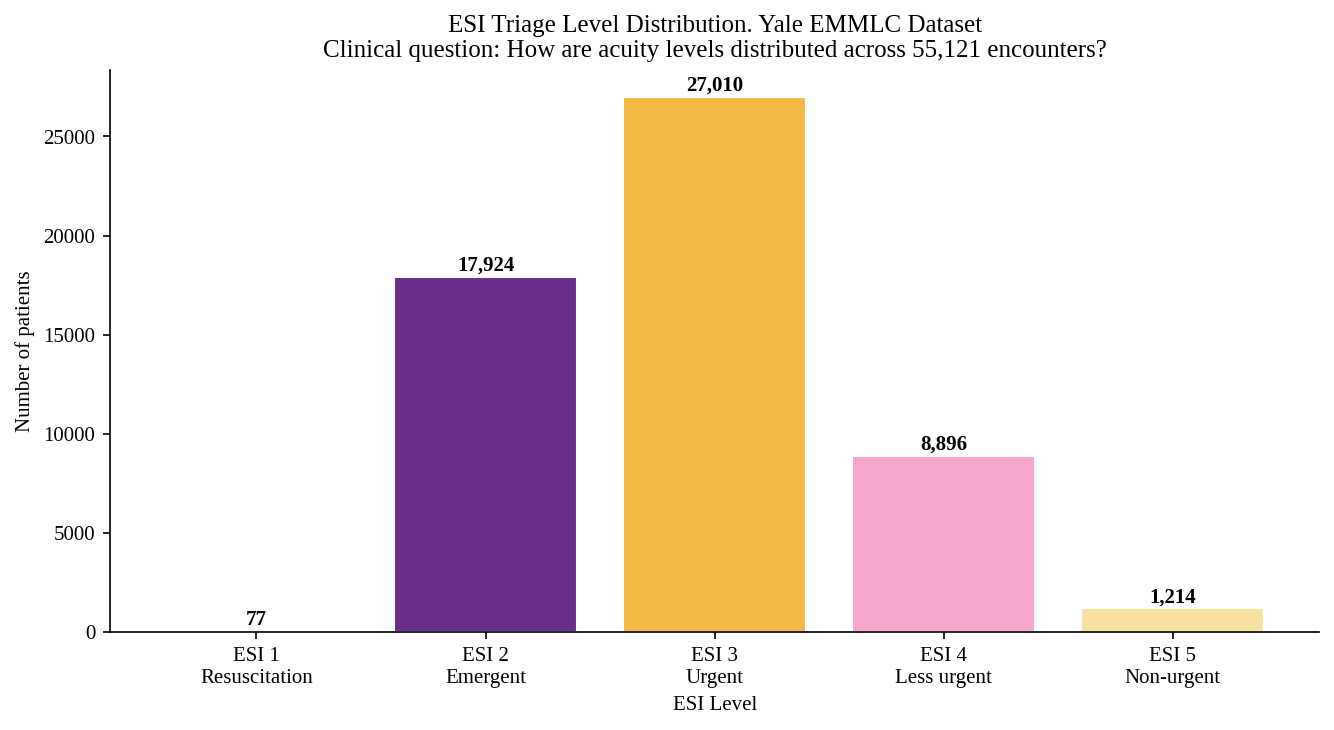

In [ ]:
ESI_LABELS = {1: "Resuscitation", 2: "Emergent", 3: "Urgent", 4: "Less urgent", 5: "Non-urgent"}
esi_counts = df["esi"].value_counts().sort_index()
esi_pct = (esi_counts / len(df) * 100).round(1)

print("ESI (Triage Level) distribution:")
for level in esi_counts.index:
    print(f"  ESI {int(level)} ({ESI_LABELS[int(level)]:<14}): {esi_counts[level]:>7,}  ({esi_pct[level]:>4}%)")
print()
print(f"Key insight: ESI 2 and 3 together account for {esi_pct[2]+esi_pct[3]:.1f}% of encounters.")
print(f"ESI 1 (most critical) represents only {esi_pct[1]}%. This is an extreme class imbalance.")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PINK, PURPLE, YELLOW, LIGHT_PINK, LIGHT_YELLOW]
bars = ax.bar([f"ESI {int(i)}\n{ESI_LABELS[int(i)]}" for i in esi_counts.index], esi_counts.values, color=colors, edgecolor="white")
for bar, val in zip(bars, esi_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300, f"{int(val):,}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("ESI Triage Level Distribution. Yale EMMLC Dataset\nClinical question: How are acuity levels distributed across 55,121 encounters?")
ax.set_ylabel("Number of patients"); ax.set_xlabel("ESI Level")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/home/claude/build/figs/plot1_esi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_esi_distribution.png")

### Plot 2. Patient Demographics (Race and Insurance)

Saved: plot2_demographics.png
Finding: 53% White or Caucasian, 29% Black or African American.
A Caribbean ED population will differ; an equity audit is required before deployment.


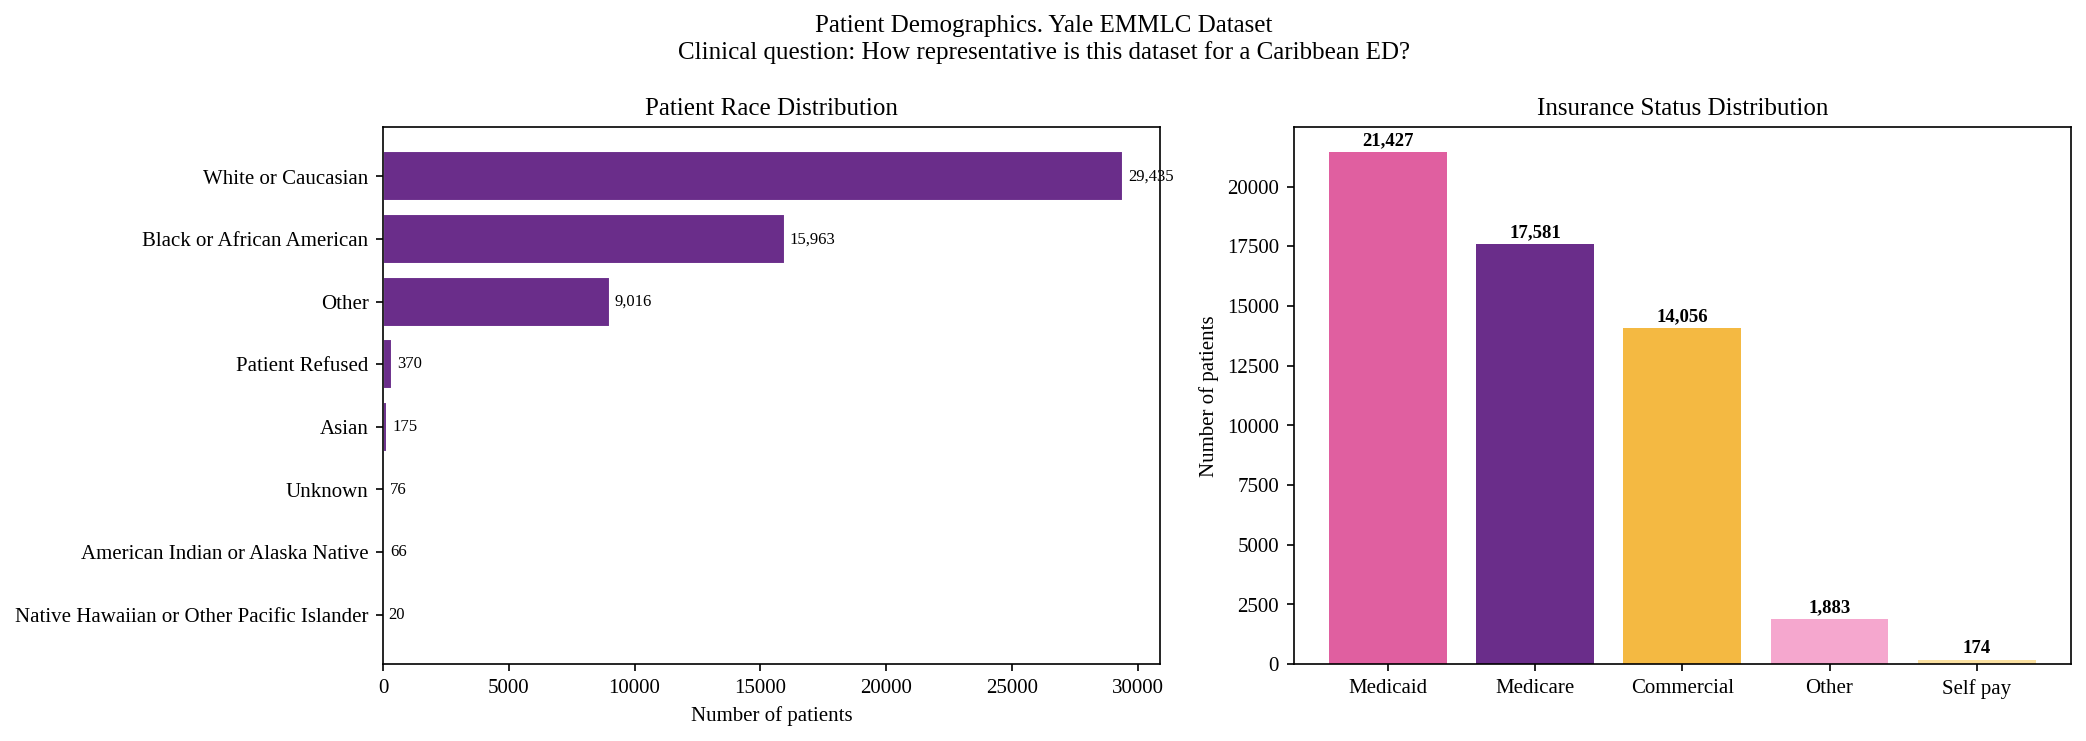

In [ ]:
race_counts = df["race"].value_counts()
insurance_counts = df["insurance_status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(race_counts.index[::-1], race_counts.values[::-1], color=PURPLE, edgecolor="white")
for i, v in enumerate(race_counts.values[::-1]):
    axes[0].text(v+200, i, f"{v:,}", va="center", fontsize=8)
axes[0].set_title("Patient Race Distribution"); axes[0].set_xlabel("Number of patients")

axes[1].bar(insurance_counts.index, insurance_counts.values, color=[PINK,PURPLE,YELLOW,LIGHT_PINK,LIGHT_YELLOW])
for i, v in enumerate(insurance_counts.values):
    axes[1].text(i, v+300, f"{v:,}", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Insurance Status Distribution"); axes[1].set_ylabel("Number of patients")

fig.suptitle("Patient Demographics. Yale EMMLC Dataset\nClinical question: How representative is this dataset for a Caribbean ED?")
plt.tight_layout()
plt.savefig("/home/claude/build/figs/plot2_demographics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot2_demographics.png")
print(f"Finding: {(race_counts.iloc[0]/len(df)*100):.0f}% {race_counts.index[0]}, "
      f"{(race_counts.iloc[1]/len(df)*100):.0f}% {race_counts.index[1]}.")
print("A Caribbean ED population will differ; an equity audit is required before deployment.")

### Plot 3. Vital Sign Distributions

Saved: plot3_vitals_distributions.png
Finding: temperature mean 98.09F confirms Fahrenheit, not Celsius.
The red dotted lines on respiratory rate and blood glucose mark the clinically
impossible cutoffs used in the outlier report above.


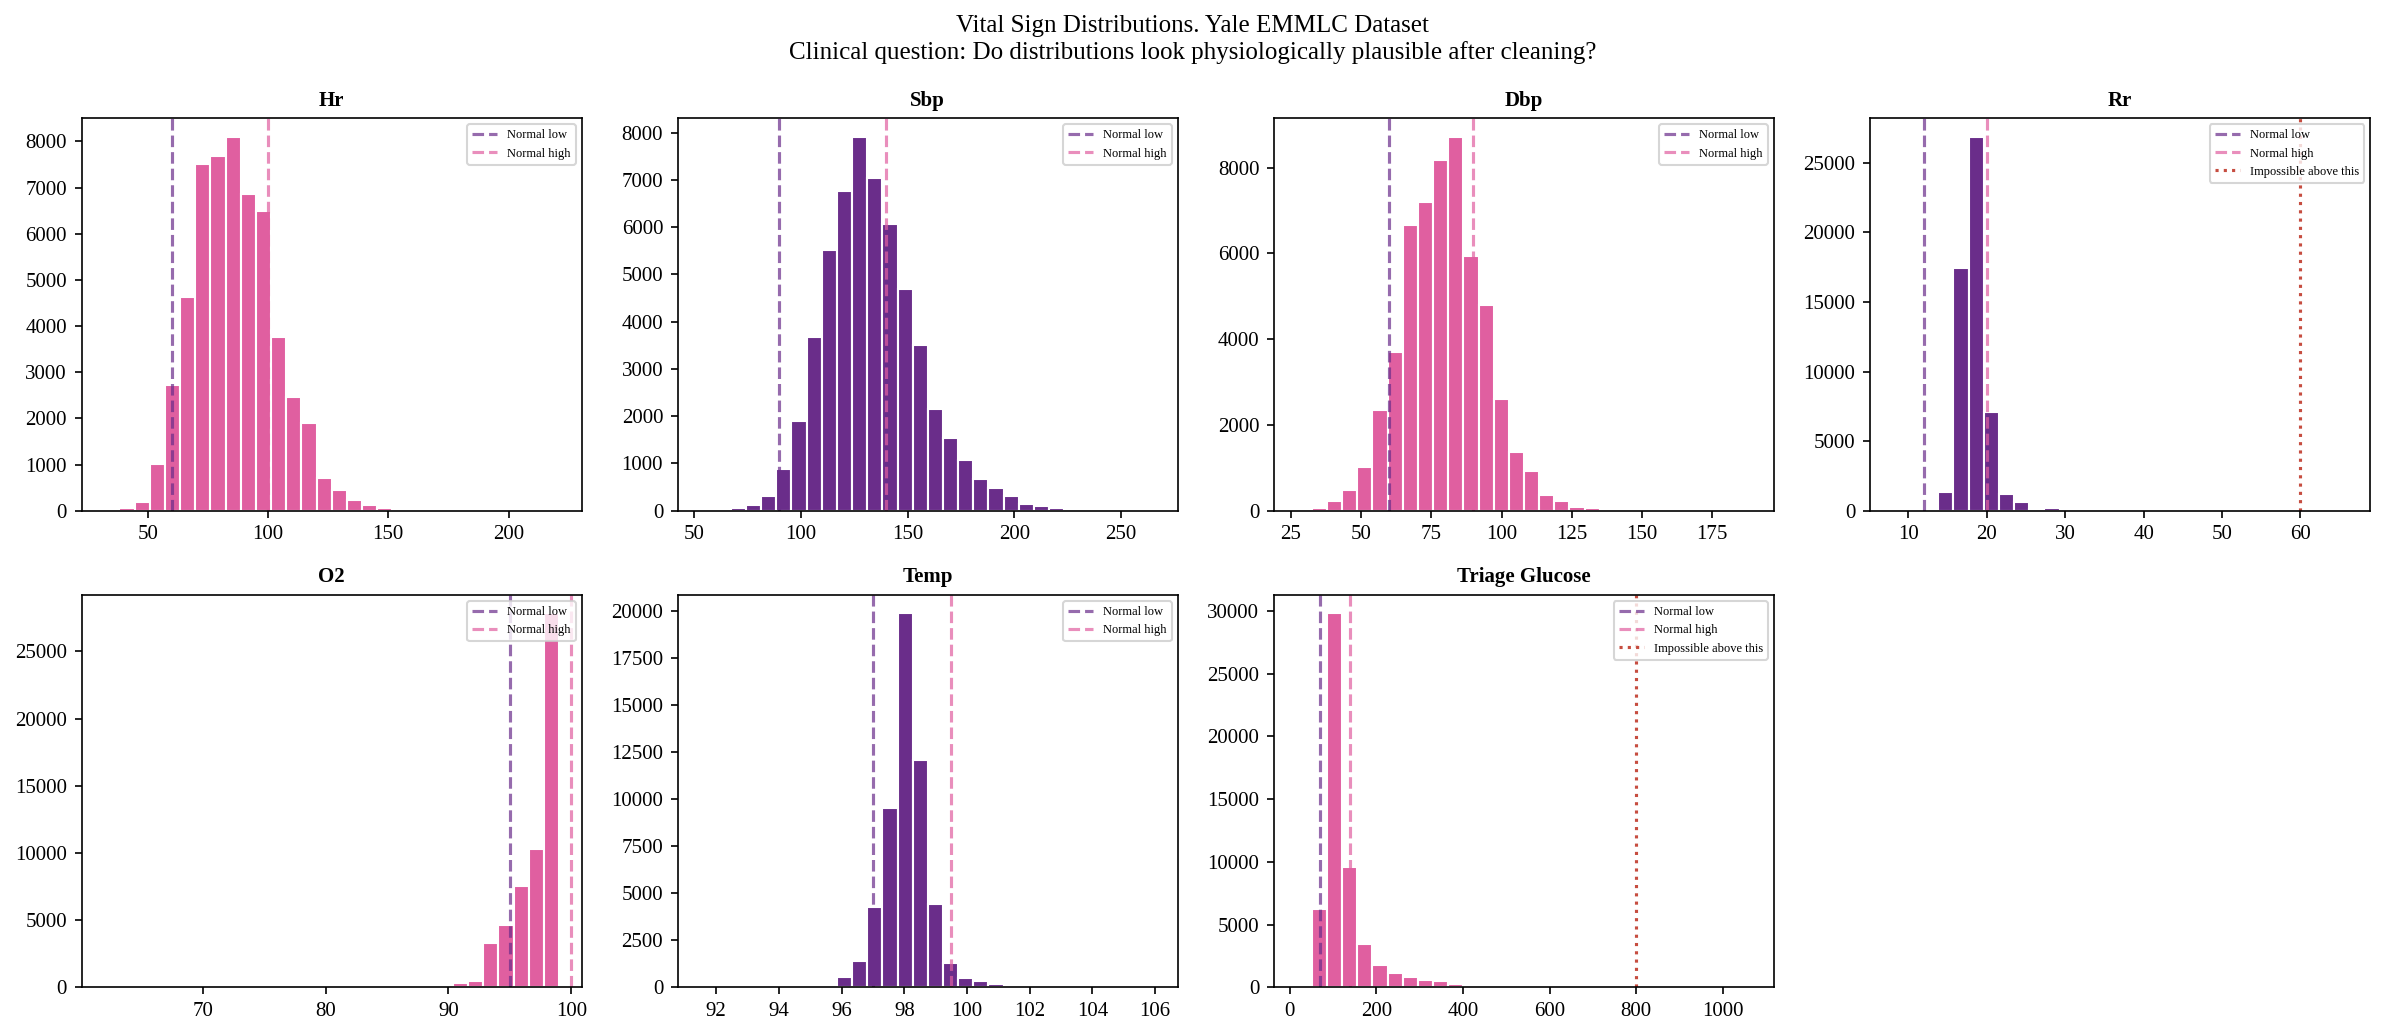

In [ ]:
NORMAL_RANGES = {"triage_vital_hr": (60,100), "triage_vital_sbp": (90,140), "triage_vital_dbp": (60,90),
                  "triage_vital_rr": (12,20), "triage_vital_o2": (95,100), "triage_vital_temp": (97.0,99.5),
                  "triage_glucose": (70,140)}
IMPOSSIBLE_CUTOFF = {"triage_vital_rr": 60, "triage_glucose": 800}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
panels = axes.ravel()
for panel, col in zip(panels, VITALS):
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(vals, bins=30, color=PINK if VITALS.index(col)%2==0 else PURPLE, edgecolor="white")
    if col in NORMAL_RANGES:
        lo, hi = NORMAL_RANGES[col]
        panel.axvline(lo, ls="--", color=PURPLE, alpha=0.7, label="Normal low")
        panel.axvline(hi, ls="--", color=PINK, alpha=0.7, label="Normal high")
    if col in IMPOSSIBLE_CUTOFF:
        panel.axvline(IMPOSSIBLE_CUTOFF[col], ls=":", color=RED, alpha=0.9, label="Impossible above this")
    panel.set_title(col.replace("triage_vital_","").replace("_"," ").title(), fontsize=10, fontweight="bold")
    panel.legend(fontsize=6, loc="upper right")
panels[-1].axis("off")
fig.suptitle("Vital Sign Distributions. Yale EMMLC Dataset\nClinical question: Do distributions look physiologically plausible after cleaning?")
plt.tight_layout()
plt.savefig("/home/claude/build/figs/plot3_vitals_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot3_vitals_distributions.png")
print(f"Finding: temperature mean {df['triage_vital_temp'].mean():.2f}F confirms Fahrenheit, not Celsius.")
print("The red dotted lines on respiratory rate and blood glucose mark the clinically")
print("impossible cutoffs used in the outlier report above.")

### Plot 4. Top Chief Complaints (and Sparsity Check)

Saved: plot4_chief_complaints.png
Finding: Abdominalpain is the most common complaint (6,717 patients).

=== Chief Complaint Sparsity ===
Total CC columns:          200
CC with < 1% prevalence:   174 of 200
CC with < 0.5% prevalence: 149 of 200
CC with 0 occurrences:     1


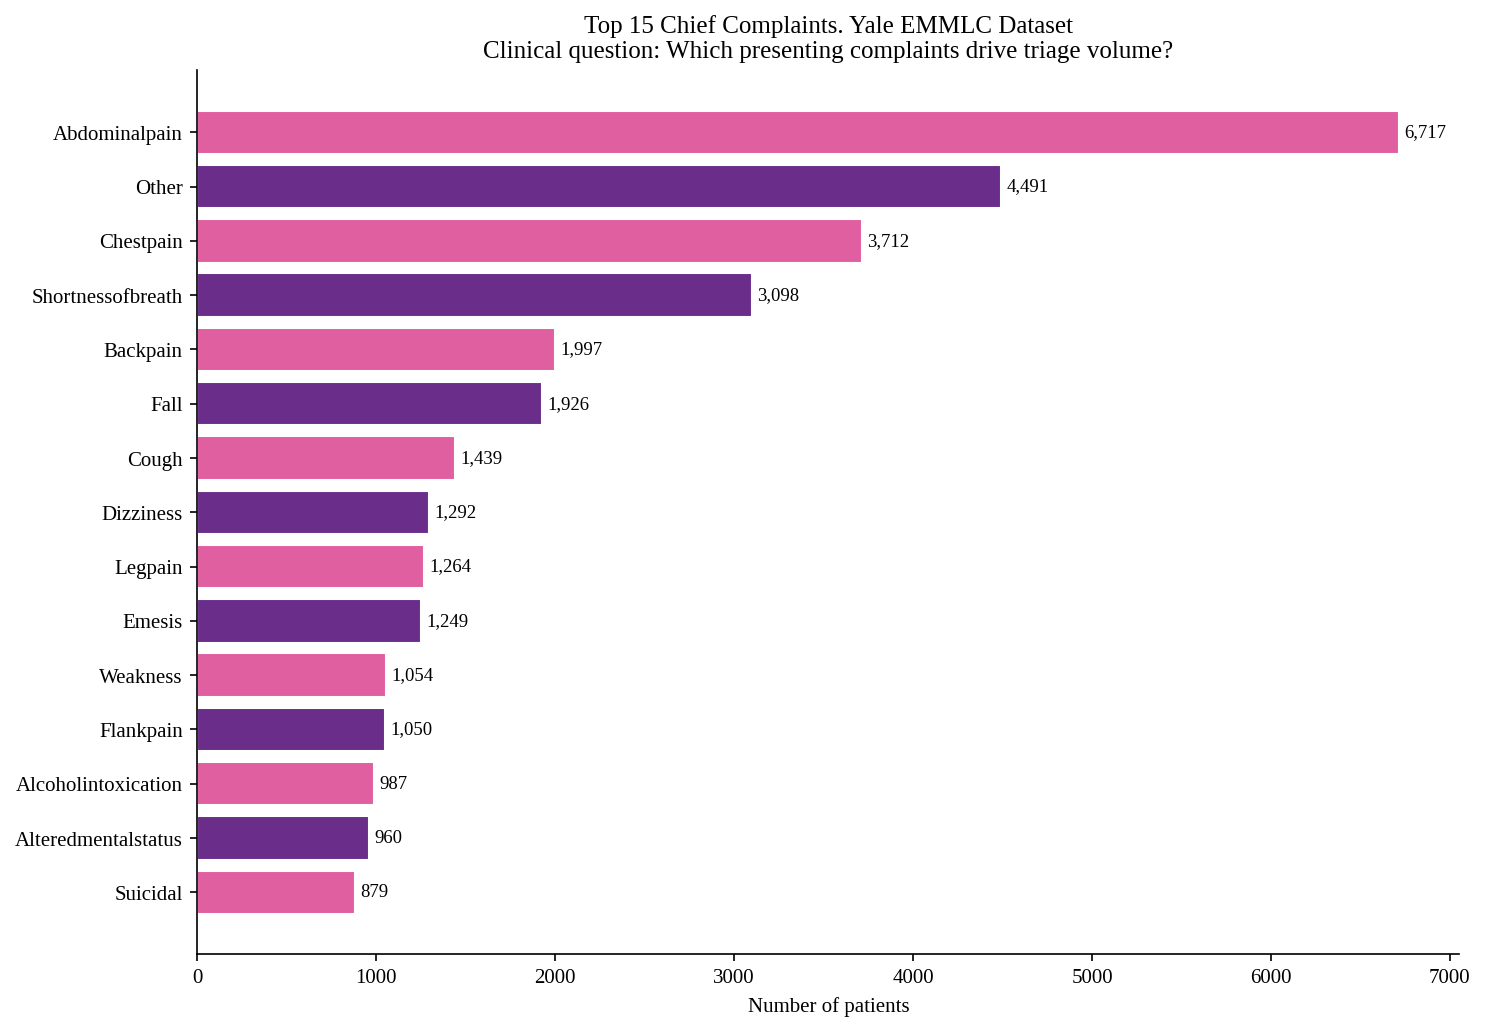

In [ ]:
cc_sums = df[CC_COLS].sum().sort_values(ascending=False)
top_cc = cc_sums.head(15)
cc_names = [name.replace("cc_", "").replace("_", " ").title() for name in top_cc.index]
bar_colors = [PINK if i % 2 == 0 else PURPLE for i in range(len(top_cc))]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cc_names[::-1], top_cc.values[::-1], color=bar_colors[::-1], edgecolor="white")
for bar, val in zip(bars, top_cc.values[::-1]):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2, f"{int(val):,}", va="center", fontsize=9)
ax.set_title("Top 15 Chief Complaints. Yale EMMLC Dataset\nClinical question: Which presenting complaints drive triage volume?")
ax.set_xlabel("Number of patients")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("/home/claude/build/figs/plot4_chief_complaints.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot4_chief_complaints.png")
print(f"Finding: {cc_names[0]} is the most common complaint ({int(top_cc.iloc[0]):,} patients).")

print()
print("=== Chief Complaint Sparsity ===")
prevalence = (df[CC_COLS].sum() / len(df) * 100)
print(f"Total CC columns:          {len(CC_COLS)}")
print(f"CC with < 1% prevalence:   {(prevalence < 1).sum()} of {len(CC_COLS)}")
print(f"CC with < 0.5% prevalence: {(prevalence < 0.5).sum()} of {len(CC_COLS)}")
print(f"CC with 0 occurrences:     {(prevalence == 0).sum()}")

## 12. Correlation with ESI

Simple linear correlation between each vital, plus age, and the ESI target, and separately for the chief complaint flags. This is **association, not causation**, but it is a reasonable first pass for ranking candidate features ahead of Week 6.

In [ ]:
age_corr = df["age"].corr(df["esi"])
vitals_numeric = df[VITALS].apply(pd.to_numeric, errors="coerce")
vital_corr = vitals_numeric.corrwith(df["esi"]).sort_values()
print("=== Correlation with ESI (negative = more predictive of high acuity) ===")
print()
print(f"  {'age':<22} r = {age_corr:>7.4f}   (higher value -> more urgent)")
for col, r in vital_corr.items():
    direction = "more urgent" if r < 0 else "less urgent"
    print(f"  {col:<22} r = {r:>7.4f}   (higher value -> {direction})")
print()
all_r = pd.concat([pd.Series({"age": age_corr}), vital_corr])
print(f"Strongest overall predictor: {all_r.abs().idxmax()} (r = {all_r[all_r.abs().idxmax()]:.3f})")
print("Clinically expected: older patients tend to present more acutely unwell.")

cc_corr = df[CC_COLS].corrwith(df["esi"]).dropna().sort_values()
print()
print("Top 8 chief complaints most associated with HIGH acuity (most negative r):")
print(cc_corr.head(8).round(3))

=== Correlation with ESI (negative = more predictive of high acuity) ===

  age                    r = -0.2366   (higher value -> more urgent)
  triage_vital_rr        r = -0.0953   (higher value -> more urgent)
  triage_vital_hr        r = -0.0952   (higher value -> more urgent)
  triage_glucose         r = -0.0778   (higher value -> more urgent)
  triage_vital_temp      r = -0.0218   (higher value -> more urgent)
  triage_vital_sbp       r =  0.0013   (higher value -> less urgent)
  triage_vital_dbp       r =  0.0465   (higher value -> less urgent)
  triage_vital_o2        r =  0.1779   (higher value -> less urgent)

Strongest overall predictor: age (r = -0.237)
Clinically expected: older patients tend to present more acutely unwell.

Top 8 chief complaints most associated with HIGH acuity (most negative r):
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psych

## 13. Demographics Summary

Full breakdown of gender, race, ethnicity, insurance status and age: the evidence base for the memo's representativeness caveat.

In [ ]:
print("=== Demographics Summary ===")
print()
print("Gender:"); print(df["gender"].value_counts())
print()
print("Race:"); print(df["race"].value_counts())
print()
print("Ethnicity:"); print(df["ethnicity"].value_counts())
print()
print("Insurance status:"); print(df["insurance_status"].value_counts())
print()
print(f"Age: mean={df['age'].mean():.1f}, median={df['age'].median():.0f}, "
      f"min={df['age'].min():.0f}, max={df['age'].max():.0f}")

=== Demographics Summary ===

Gender:
gender
Female    31744
Male      23377
Name: count, dtype: int64

Race:
race
White or Caucasian                           29435
Black or African American                    15963
Other                                         9016
Patient Refused                                370
Asian                                          175
Unknown                                         76
American Indian or Alaska Native                66
Native Hawaiian or Other Pacific Islander       20
Name: count, dtype: int64

Ethnicity:
ethnicity
Non-Hispanic          45142
Hispanic or Latino     9888
Patient Refused          56
Unknown                  35
Name: count, dtype: int64

Insurance status:
insurance_status
Medicaid      21427
Medicare      17581
Commercial    14056
Other          1883
Self pay        174
Name: count, dtype: int64

Age: mean=55.3, median=55, min=18, max=107


## 14. Wrap Up

**What this notebook established.**
- The dataset loads cleanly. 55,121 encounters by 225 columns, zero missing values anywhere.
- Two dtype issues were found, the `esi` target and 201 binary flags stored as `float64`. Cosmetic for now, worth casting before modelling.
- 29 clinically impossible values (4 respiratory rate, 25 glucose) were identified and require correction.
- `disposition` and `previousdispo` are confirmed leakage and excluded from every feature set.
- Age (r equals negative 0.24) and oxygen saturation (r equals positive 0.18) are the strongest linear correlates of ESI among structured features.

**Next steps.**
- The full feasibility memo, built from this evidence, is at `docs/week5_feasibility_memo.md`.
- The four dashboard plots and the missingness heatmap are committed to `docs/figures/`.
- Week 6 picks up from here. Clean the 29 impossible values, drop near zero variance chief complaint flags and train a baseline classifier on the real `esi` target.